# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs

## Ce que sont les LLMs et à quoi ils servent

Un LLM (Large Language Model) est un programme informatique entraîné
sur des quantités massives de textes — des milliards de phrases issues
d'internet, de livres, d'articles — pour apprendre le langage humain.

Son principe de base est simple : **prédire le prochain mot** dans une phrase.
Par exemple, si on lui donne "Je vais au marché d'", il peut prédire
"Adjamé" parce qu'il a vu des millions de phrases similaires pendant
son entraînement.

En répétant cette tâche des milliards de fois sur des textes variés,
le modèle finit par apprendre bien plus que la grammaire : il comprend
le contexte, les faits, la logique, et même des notions culturelles.

### À quoi servent les LLMs ?

Les LLMs sont conçus pour de nombreuses tâches liées au langage :

- **Génération de texte** : écrire des articles, des emails, des résumés
- **Réponse aux questions** : comme un assistant intelligent
- **Traduction** : passer d'une langue à une autre
- **Classification** : détecter si un SMS est un spam ou non
- **Génération de code** : écrire du Python, du JavaScript, etc.

### Exemples populaires

GPT-2, GPT-4 (OpenAI), Claude (Anthropic), Gemini (Google)
sont tous des LLMs. Ils utilisent tous la même architecture de base
appelée **Transformer**, introduite en 2017.


### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [ ]:
%pip install --quiet transformers matplotlib --upgrade


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = "gpt2"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


## La tokenisation — explication

La tokenisation est le processus qui consiste à découper un texte brut
en petits morceaux appelés **tokens**. Chaque token reçoit ensuite un
numéro unique (ID) car les modèles de langage ne comprennent que des chiffres.

Par exemple : "Je mange du attiéké" devient
["Je", "Ġmange", "Ġdu", "Ġatt", "ié", "ké"] → [17, 33423, 7110, ...]

Le symbole Ġ indique qu'il y a un espace avant ce token.

Original Text: I love eating attiéké with grilled fish in Abidjan
Tokens: ['I', 'Ġlove', 'Ġeating', 'Ġatt', 'i', 'Ã©', 'k', 'Ã©', 'Ġwith', 'Ġgrilled', 'Ġfish', 'Ġin', 'ĠAb', 'id', 'jan']
Token IDs: [40, 1842, 6600, 708, 72, 2634, 74, 2634, 351, 34240, 5916, 287, 2275, 312, 13881]


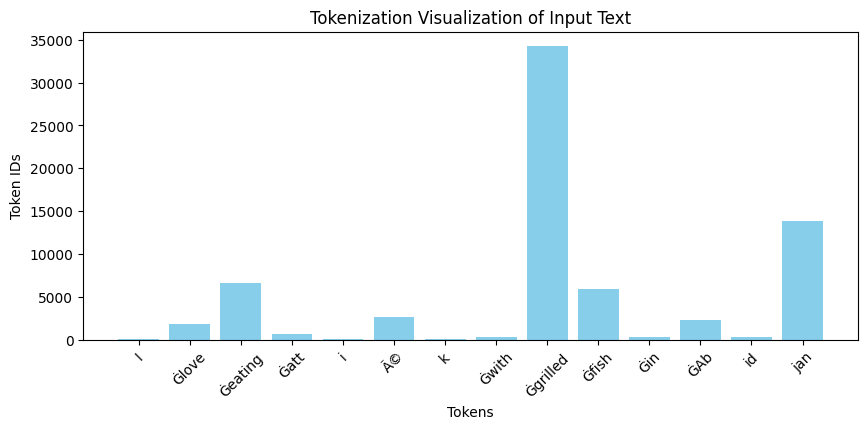

In [2]:
text = "I love eating attiéké with grilled fish in Abidjan"
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

# Labels et titre du graphique
x_label = "Tokens"
y_label = "Token IDs"
title   = "Tokenization Visualization of Input Text"

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()


## 🌟 Exercise 3 · Token IDs and special prefixes


In [5]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# Afficher chaque token avec son ID
for token, token_id in zip(tokens, token_ids):
    print(f"'{token}' → {token_id}")


'I' → 40
'Ġlove' → 1842
'Ġeating' → 6600
'Ġatt' → 708
'i' → 72
'Ã©' → 2634
'k' → 74
'Ã©' → 2634
'Ġwith' → 351
'Ġgrilled' → 34240
'Ġfish' → 5916
'Ġin' → 287
'ĠAb' → 2275
'id' → 312
'jan' → 13881


## Le préfixe Ġ dans GPT-2

Le symbole `Ġ` indique qu'il y a **un espace avant ce token** dans le texte original.

C'est la façon dont le tokenizer BPE (Byte Pair Encoding) de GPT-2
encode les espaces : au lieu de les traiter séparément, il les attache
au début du mot suivant.

Exemples :
- `"I"` → pas de Ġ car c'est le premier mot de la phrase
- `"Ġlove"` → le Ġ signifie qu'il y avait un espace avant "love"
- `"Ġatt"` → espace avant le début du mot "attiéké"

Cela permet au modèle de reconstruire exactement le texte original
avec ses espaces, même après découpage en sous-mots.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [6]:
# Créer le générateur
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

# Nouveau prompt
input_text = "In Abidjan, the streets are full of"

# Paramètres de génération
gen_kwargs = {
    "max_new_tokens": 60,   # longueur de la génération
    "temperature": 0.8,     # créativité (0=prudent, 1=créatif)
    "top_p": 0.95,          # diversité des mots choisis
    "do_sample": True,      # activer l'échantillonnage aléatoire
}

# Générer
output_ids  = generator(input_text, **gen_kwargs)
output_text = output_ids[0]["generated_text"]

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'max_new_tokens', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: In Abidjan, the streets are full of
Generated Output: In Abidjan, the streets are full of people protesting against corruption and the brutal rule of the ruling ZANU-PF.

"The police are not doing their job and if they see us they will not move," a girl said.

"I am going to protest and I want to stop the government from taking us to


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)